In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from tqdm import tqdm

In [48]:
ANNOTATIONS_CSV = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train_robo_1/_annotations.csv'
IMAGE_DIR = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train_robo_1'
TEST_IMAGE_DIR = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/test'

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 13
INPUT_SIZE = 224

CSV_PATH = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/train.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [49]:
annotations = pd.read_csv(ANNOTATIONS_CSV)
class_names = sorted(annotations['class'].unique())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
annotations['class_idx'] = annotations['class'].map(class_to_idx)

train_ann, val_ann = train_test_split(annotations, test_size=0.2, stratify=annotations['class'], random_state=42)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [50]:
class ChocolateDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.annotations = annotations.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        # self.image_filenames = self.annotations['filename'].unique()
        self.image_filenames = self.annotations['filename'].astype(str).unique().tolist()

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]        
        image_path = os.path.join(self.image_dir, row['filename'])
        image = Image.open(image_path).convert("RGB")
        cropped = image.crop((row['xmin'], row['ymin'], row['xmax'], row['ymax']))
        if self.transform: 
            cropped = self.transform(cropped)
        label = row['class_idx']

        return cropped, label

In [51]:
train_dataset = ChocolateDataset(train_ann, IMAGE_DIR, transform)
val_dataset = ChocolateDataset(val_ann, IMAGE_DIR, transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [52]:
# === MODEL ===
class VGGDetector(nn.Module):
    def __init__(self, num_classes):
        super(VGGDetector, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = VGGDetector(NUM_CLASSES).to(device)

In [53]:
# === TRAINING ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
    val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

100%|██████████| 38/38 [03:00<00:00,  4.74s/it]


Epoch 1/10 - Train Loss: 2.6325, Val Loss: 2.5536


100%|██████████| 38/38 [03:02<00:00,  4.81s/it]


Epoch 2/10 - Train Loss: 2.3742, Val Loss: 2.3791


100%|██████████| 38/38 [02:55<00:00,  4.62s/it]


...

Epoch 8/10 - Train Loss: 0.2819, Val Loss: 0.1709


100%|██████████| 38/38 [02:56<00:00,  4.65s/it]


Epoch 9/10 - Train Loss: 0.3715, Val Loss: 0.2720


100%|██████████| 38/38 [02:57<00:00,  4.68s/it]


Epoch 10/10 - Train Loss: 0.1492, Val Loss: 0.2869


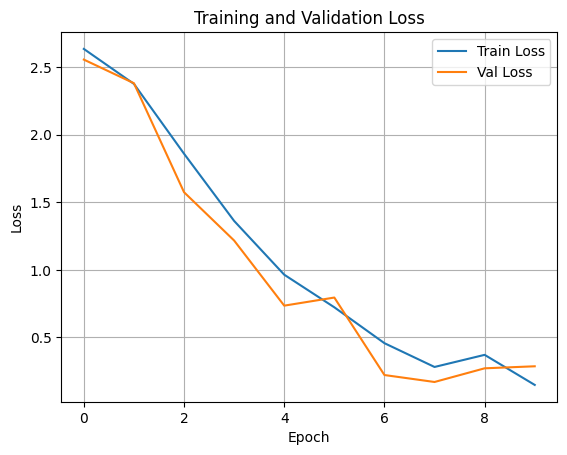

In [54]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
# === PREDICTION FUNCTION ===
def predict_and_create_submission(model, submission_template_path, output_csv_path):
    submission_df = pd.read_csv(submission_template_path)
    image_ids = submission_df['id'].tolist()
    filenames = ['L' + str(i) + '.JPG' for i in image_ids]
    results = []
    model.eval()

    for img_id, fname in zip(image_ids, filenames):
        img_path = os.path.join(TEST_IMAGE_DIR, fname)
        if not os.path.exists(img_path):
            print(f"Missing image: {img_path}")
            results.append([img_id] + [0]*NUM_CLASSES)
            continue

        image = Image.open(img_path).convert('RGB')
        image = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(image)
            probs = torch.softmax(output, dim=1)
            predicted_class = torch.argmax(probs, dim=1).item()

        counts = [0] * NUM_CLASSES
        counts[predicted_class] = 1
        results.append([img_id] + counts)

    result_df = pd.DataFrame(results, columns=['id'] + class_names)
    result_df.to_csv(output_csv_path, index=False)
    print(f"Submission saved to {output_csv_path}")

In [57]:
sample_submission_path = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/sample_submission.csv'
output_submission_path = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/predictions/ann_submission.csv'
predict_and_create_submission(model, sample_submission_path, output_submission_path)

Submission saved to C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/predictions/ann_submission.csv
